In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import streamlit
import seaborn as sns
import pickle

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

In [3]:
df = pd.read_csv('IceCreamSalesData.csv')
df

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531
5,-3.455712,30.001138
6,-3.108440,22.635401
7,-3.081303,25.365022
8,-2.672461,19.226970
9,-2.652287,20.279679


In [4]:
df.shape

(49, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


In [6]:
df.describe()

,Temperature (°C),Ice Cream Sales (units)
count,49.000000,49.000000
mean,0.271755,15.905308
std,2.697672,12.264682
min,-4.662263,0.328626
25%,-2.111870,4.857988
50%,0.688781,12.615181
75%,2.784836,25.142082
max,4.899032,41.842986


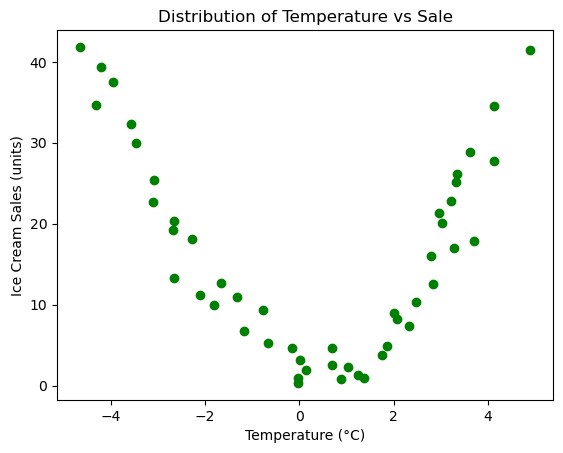

In [7]:
# Scatter Plot


plt.scatter(df['Temperature (°C)'], df['Ice Cream Sales (units)'], color = 'green')
plt.title("Distribution of Temperature vs Sale")
plt.xlabel("Temperature (°C)")
plt.ylabel("Ice Cream Sales (units)")
plt.show()

In [8]:
# Check Co-relation

corr = df.corr()
corr

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


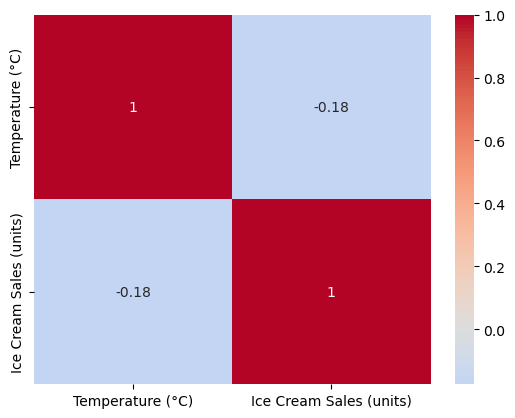

In [9]:
sns.heatmap(corr, annot = True, cmap = 'coolwarm', center = 0)
plt.show()

In [10]:
# Seperate the Features and target

X = df[['Temperature (°C)']]    # Input Feature
y = df['Ice Cream Sales (units)']    # Target Feature

In [11]:
X

,Temperature (°C)
0,-4.662263
1,-4.316559
2,-4.213985
3,-3.949661
4,-3.578554
5,-3.455712
6,-3.108440
7,-3.081303
8,-2.672461
9,-2.652287


In [12]:
y

0     41.842986
1     34.661120
2     39.383001
3     37.539845
4     32.284531
5     30.001138
6     22.635401
7     25.365022
8     19.226970
9     20.279679
10    13.275828
11    18.123991
12    11.218294
13    10.012868
14    12.615181
15    10.957731
16     6.689123
17     9.392969
18     5.210163
19     4.673643
20     0.328626
21     0.897603
22     3.165600
23     1.931416
24     2.576782
25     4.625689
26     0.789974
27     2.313806
28     1.292361
29     0.953115
30     3.782570
31     4.857988
32     8.943823
33     8.170735
34     7.412094
35    10.336631
36    15.996620
37    12.568237
38    21.342916
39    20.114413
40    22.839406
41    16.983279
42    25.142082
43    26.104740
44    28.912188
45    17.843957
46    34.530743
47    27.698383
48    41.514822
Name: Ice Cream Sales (units), dtype: float64

In [13]:
# Train-Test Split
# We split the data to evaluate model performance
# Same rows are taken for split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [14]:
X_train

,Temperature (°C)
12,-2.111870
4,-3.578554
34,2.318591
8,-2.672461
3,-3.949661
6,-3.108440
40,3.211366
41,3.270044
46,4.130868
15,-1.326379


In [15]:
X_train.size          # No. of elements. size is a property or instance.

39

In [16]:
X_test.size

10

In [17]:


# Standard Scaler

scaler = StandardScaler()

scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [18]:
scaled_X_train

array([[-7.63693745e-01],
       [-1.29300680e+00],
       [ 8.35219704e-01],
       [-9.66006037e-01],
       [-1.42693611e+00],
       [-1.12334704e+00],
       [ 1.15741413e+00],
       [ 1.17859046e+00],
       [ 1.48925405e+00],
       [-4.80217223e-01],
       [-9.58725410e-01],
       [-4.24908615e-01],
       [ 2.47035833e-01],
       [ 7.47346123e-01],
       [ 6.26411340e-01],
       [-1.68410760e+00],
       [ 1.20236897e+00],
       [ 7.19994113e-01],
       [-1.24867422e+00],
       [ 4.89205154e-01],
       [-8.27352862e-01],
       [ 1.00348341e+00],
       [-1.55934642e+00],
       [-1.37714965e-02],
       [-1.52232814e+00],
       [ 1.02041776e+00],
       [ 8.90564054e-01],
       [ 5.23220294e-02],
       [ 1.08866734e+00],
       [-9.58440754e-01],
       [ 1.56744775e-03],
       [-2.44690311e-01],
       [ 1.76647736e+00],
       [-1.45875476e-02],
       [-1.11355361e+00],
       [ 1.19520171e+00],
       [-6.00743535e-01],
       [ 4.46222656e-01],
       [ 1.0

In [19]:
scaled_X_test

array([[-0.65797719],
       [ 1.33522198],
       [ 1.49021612],
       [ 1.30155844],
       [-0.28062684],
       [ 0.36807864],
       [ 0.31420635],
       [ 0.24877459],
       [ 0.66630853],
       [-0.05554087]])

In [20]:
# Training Linear Regression Model

regression = LinearRegression()
regression.fit(scaled_X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
coef = regression.coef_
intercept = regression.intercept_

print(f'coefficient: {coef}')
print(f'intercept: {intercept}')

coefficient: [-3.17710024]
intercept: 17.13432359205404


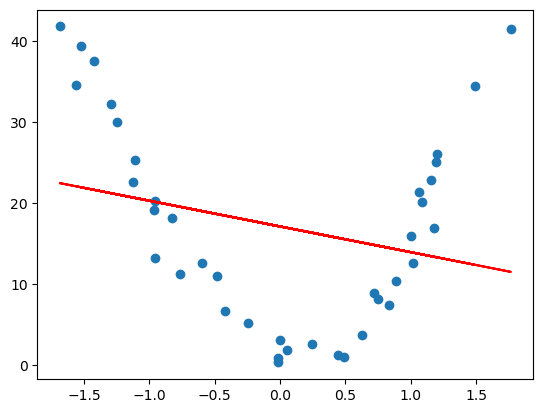

In [22]:
# Plot Best Fit line

plt.scatter(scaled_X_train, y_train)
plt.plot(scaled_X_train, regression.predict(scaled_X_train), 'r')
plt.show()

In [23]:
# Prediction on Test Data

y_pred_test = regression.predict(scaled_X_test)
y_pred_test

array([19.2247831 , 12.89218952, 12.39975758, 12.99914196, 18.0259032 ,
       15.96490086, 16.13605851, 16.34394177, 15.0173946 , 17.3107825 ])

In [24]:
#  Model Evaluation (Metrics):

# Mean Absolute Error (MAE)
# Mean Squared Error (MSE)
# Root Mean Square Error (RMSE)
# R-square Score (R2_Score)

def test_metrics(y_test, y_pred_test):             # 'y_test, y_pred_test' These are parameters.
   result = [{                                     # 'result' is a variable.
       'MAE': mean_absolute_error(y_test, y_pred_test),
       'MSE': mean_squared_error(y_test, y_pred_test),
       'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)),
       'R2_SCORE': r2_score(y_test, y_pred_test)
   }]
   return pd.DataFrame(result)

In [25]:
metrics = test_metrics(y_test, y_pred_test)
metrics

,MAE,MSE,RMSE,R2_SCORE
0,11.752027,149.326291,12.219914,-0.575127


# Poylnomial Regression

In [26]:
# Polynomial Regression

poly = PolynomialFeatures(degree = 2, include_bias = False)
poly

,degree,2
,interaction_only,False
,include_bias,False
,order,'C'


In [27]:
# According to Polynomial Features degree = 2

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [28]:
X_train_poly

array([[-2.11186969e+00,  4.45999359e+00],
       [-3.57855372e+00,  1.28060467e+01],
       [ 2.31859124e+00,  5.37586534e+00],
       [-2.67246083e+00,  7.14204687e+00],
       [-3.94966109e+00,  1.55998227e+01],
       [-3.10844012e+00,  9.66239999e+00],
       [ 3.21136614e+00,  1.03128725e+01],
       [ 3.27004407e+00,  1.06931882e+01],
       [ 4.13086796e+00,  1.70640701e+01],
       [-1.32637898e+00,  1.75928121e+00],
       [-2.65228679e+00,  7.03462523e+00],
       [-1.17312327e+00,  1.37621820e+00],
       [ 6.88780908e-01,  4.74419139e-01],
       [ 2.07510060e+00,  4.30604249e+00],
       [ 1.74000001e+00,  3.02760004e+00],
       [-4.66226268e+00,  2.17366933e+01],
       [ 3.33593241e+00,  1.11284451e+01],
       [ 1.99931037e+00,  3.99724195e+00],
       [-3.45571170e+00,  1.19419433e+01],
       [ 1.35981267e+00,  1.84909051e+00],
       [-2.28826400e+00,  5.23615213e+00],
       [ 2.78483646e+00,  7.75531413e+00],
       [-4.31655945e+00,  1.86326855e+01],
       [-3.

In [29]:
X_test_poly

array([[-1.81893761,  3.30853403],
       [ 3.70405744, 13.72004151],
       [ 4.13353379, 17.08610158],
       [ 3.61077848, 13.03772121],
       [-0.77333004,  0.59803936],
       [ 1.02418081,  1.04894634],
       [ 0.87490503,  0.76545881],
       [ 0.69359887,  0.4810794 ],
       [ 1.85055193,  3.42454243],
       [-0.14963487,  0.02239059]])

In [30]:
# Model Training

regression = LinearRegression()

regression.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
coef = regression.coef_
intercept = regression.intercept_

print(f'coefficient: {coef}')
print(f'intercept: {intercept}')

coefficient: [-0.70641926  1.87145125]
intercept: 2.76830582957386


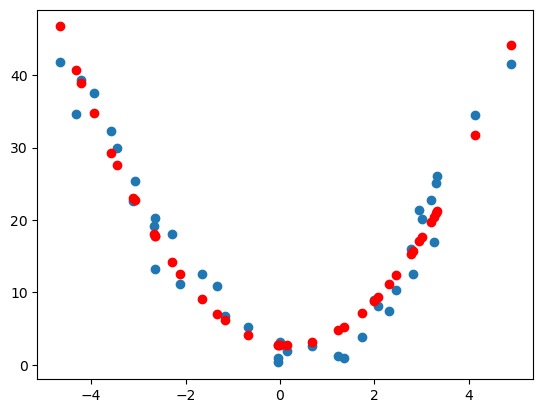

In [32]:
plt.scatter(X_train, y_train)
plt.scatter(X_train, regression.predict(X_train_poly), color = "r")

In [33]:
# Prediction

y_pred_test = regression.predict(X_test_poly)
y_pred_test

array([10.24499852, 25.82807714, 31.8241041 , 24.61704203,  4.43380256,
        4.00785672,  3.58277491,  3.17865087,  7.86990452,  2.91591368])

In [34]:
metrics = test_metrics(y_test, y_pred_test)
metrics

,MAE,MSE,RMSE,R2_SCORE
0,3.229982,14.878796,3.857304,0.843055


In [35]:
def poly_regression(degree):
    scaler = StandardScaler()
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    regression = LinearRegression()

    pipeline = Pipeline([
        ('scaler', scaler),
        ('poly', poly),
        ('regression', regression),
    ])

    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    print(score)

    X_sorted = X_train.sort_values(by=X_train.columns[0])
    y_pred = pipeline.predict(X_sorted)

    plt.plot(X_sorted, y_pred, "r", label="Model fit")
    plt.scatter(X_train, y_train, label="Traning Points")
    plt.scatter (X_test, y_test, label="Test Points")
    plt.legend()
    plt.show()

-0.5751270190188227


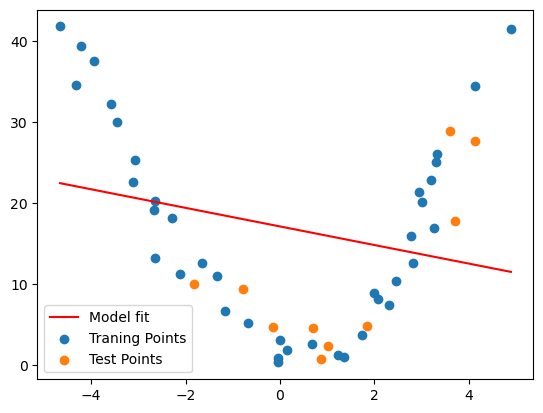

0.843055137193884


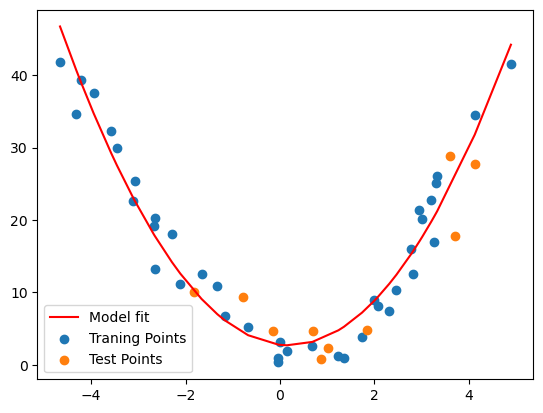

0.8405107685716919


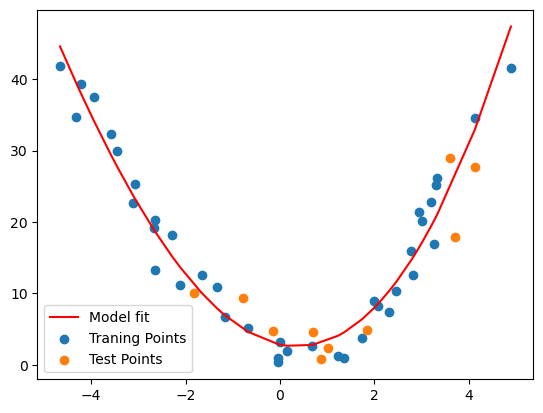

0.8054468908427665


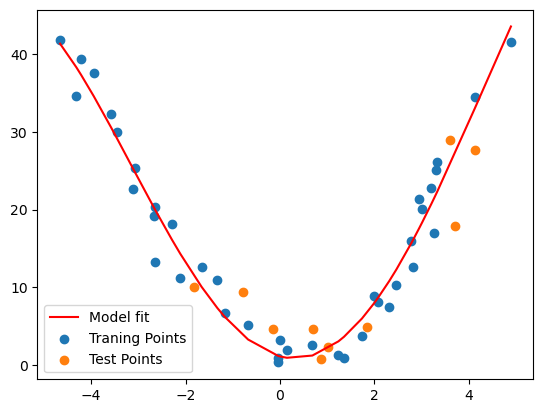

0.7781622233034697


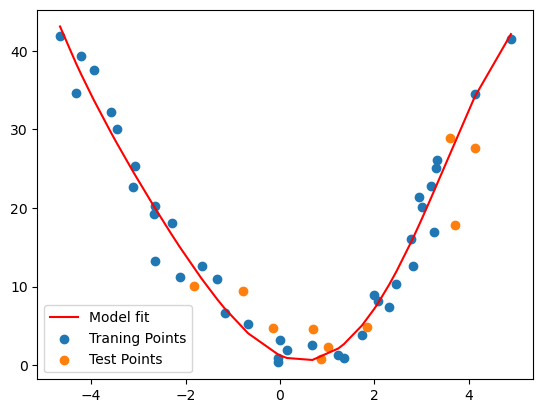

0.7313950333962964


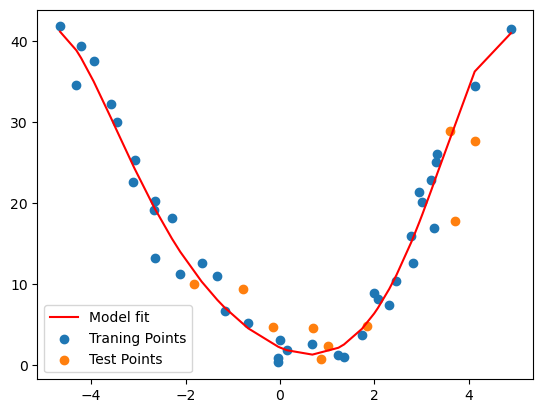

0.7690369411276904


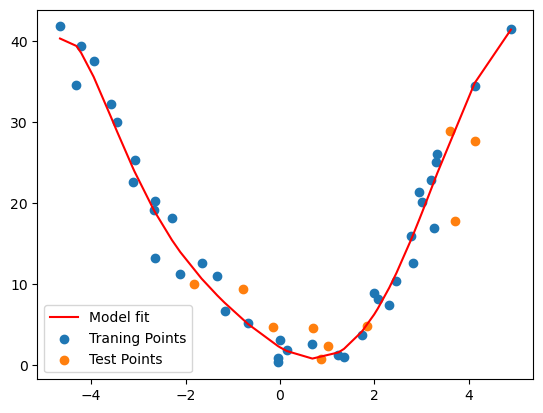

0.7759596479486373


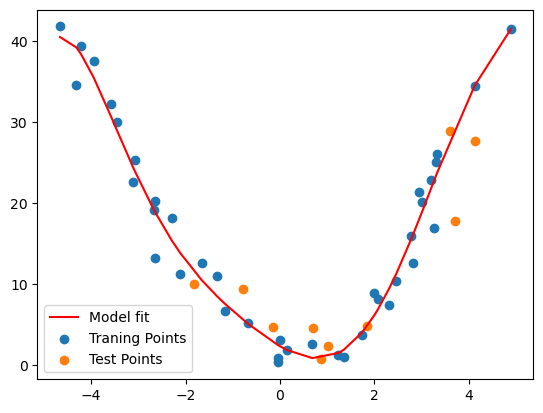

0.7741537994038167


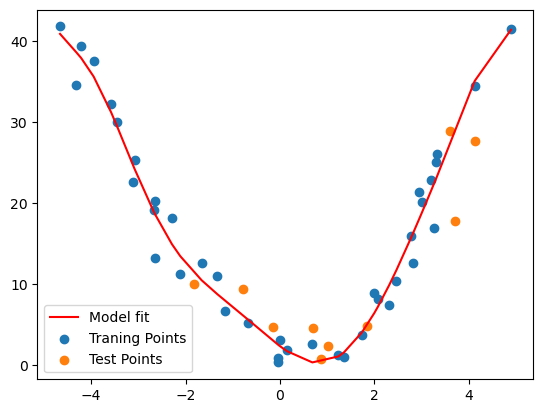

0.7432997364943192


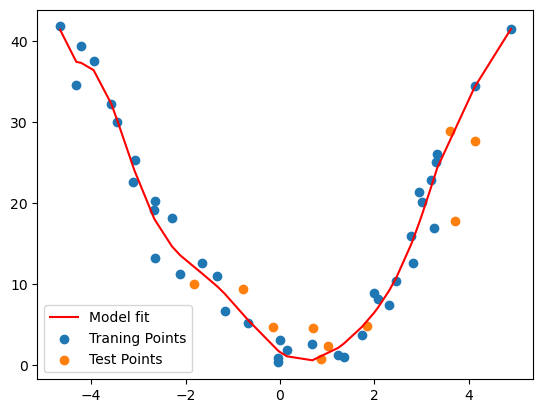

In [36]:
for degree in [1,2,3,4,5,6,7,8,9,10]:
     poly_regression(degree)

In [37]:
# save model
pickle.dump(regression, open("model.pkl","wb"))
print("Model trained and saved successfully!")

Model trained and saved successfully!


In [38]:
# pip install streamlit[charts]